In [19]:
import numpy as np

# SHO period data (for 5 cycles each)
sho_periods = np.array(
    [
        [5.62, 5.60, 5.55, 5.49, 5.79],  # -2.00 A
        [6.35, 5.94, 6.15, 6.38, 6.36],  # -1.75 A
        [6.56, 6.74, 6.54, 7.03, 6.70],  # -1.50 A
        [7.91, 7.32, 7.64, 7.41, 7.27],  # -1.25 A
        [8.40, 8.13, 8.29, 8.21, 8.28],  # -1.00 A
    ]
)


field_strengths = np.array([13.9, 11.7, 10.1, 8.3, 6.4])  # Gauss
field_strengths = field_strengths * 1e-4  # T

m = 183.0  # g
r = 28.5  # mm
m = m * 1e-3  # kg
r = r * 1e-3  # m

I = (2 / 5) * m * r**2

print(sho_periods.shape)
print(sho_periods)

(5, 5)
[[5.62 5.6  5.55 5.49 5.79]
 [6.35 5.94 6.15 6.38 6.36]
 [6.56 6.74 6.54 7.03 6.7 ]
 [7.91 7.32 7.64 7.41 7.27]
 [8.4  8.13 8.29 8.21 8.28]]


In [20]:
def round_unc(value, uncertainty, cutoff=2, extract_magnitude=False):
    scalar_input = np.isscalar(value)

    value = np.atleast_1d(value).astype(float)
    uncertainty = np.atleast_1d(uncertainty).astype(float)

    exp = np.floor(np.log10(np.abs(uncertainty)))
    first_digit = (uncertainty / 10**exp).astype(int)
    sigs = np.where(first_digit <= cutoff, 2, 1)

    rounding_decimals = (-exp + (sigs - 1)).astype(int)
    rounded_uncertainty = (
        np.round(uncertainty * 10.0**rounding_decimals) / 10.0**rounding_decimals
    )

    decimals = (-np.floor(np.log10(rounded_uncertainty)) + (sigs - 1)).astype(int)
    rounded_value = np.round(value * 10.0**decimals) / 10.0**decimals

    if extract_magnitude:
        exponent = np.floor(np.log10(np.abs(rounded_value))).astype(int)
        mantissa_value = rounded_value / 10.0**exponent
        mantissa_uncertainty = rounded_uncertainty / 10.0**exponent

        if scalar_input:
            return mantissa_value[0], mantissa_uncertainty[0], exponent[0]
        return mantissa_value, mantissa_uncertainty, exponent

    if scalar_input:
        return rounded_value[0], rounded_uncertainty[0]
    return rounded_value, rounded_uncertainty

In [21]:
sho_periods_mean = sho_periods.mean(axis=1) / 5.5
sho_periods_unc = (sho_periods / 5.5).std(axis=1) / np.sqrt(5)

$$
\left ( \frac{2\pi}{T} \right )^2 =  \mu \cdot \frac{B}{I}
$$


$$
T^2 =\frac{4 \pi^2 I}{\mu B}
$$


$$
\frac{T^2}{4 \pi ^2} = \frac{I}{\mu B}
$$


In [22]:
import pandas as pd

df = pd.DataFrame()

In [23]:
sho_periods

array([[5.62, 5.6 , 5.55, 5.49, 5.79],
       [6.35, 5.94, 6.15, 6.38, 6.36],
       [6.56, 6.74, 6.54, 7.03, 6.7 ],
       [7.91, 7.32, 7.64, 7.41, 7.27],
       [8.4 , 8.13, 8.29, 8.21, 8.28]])

In [24]:
df["T"] = sho_periods_mean
df["B"] = field_strengths
df["2pi_upon_T_sq"] = ((2 * np.pi) / df["T"]) ** 2
df["B_upon_I"] = df["B"] / I

df

,T,B,2pi_upon_T_sq,B_upon_I
0,1.020000,0.00139,37.945423,23.378358
1,1.133818,0.00117,30.709511,19.678186
2,1.220727,0.00101,26.492469,16.987152
3,1.365455,0.00083,21.174114,13.959739
4,1.502182,0.00064,17.495032,10.764136


In [25]:
from scipy import stats

slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["B_upon_I"], df["2pi_upon_T_sq"]
)

print(f"Slope (mu): {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")
print(f"p-value: {p_value}")


Slope (mu): 1.6325555820077162
Intercept: -0.9142443194334966
R-squared: 0.9921254268676053
p-value: 0.0002972750700544565


In [26]:
import matplotlib.pyplot as plt

Text(0, 0.5, '$(2\\pi/T)^2$ (s$^{-2}$)')

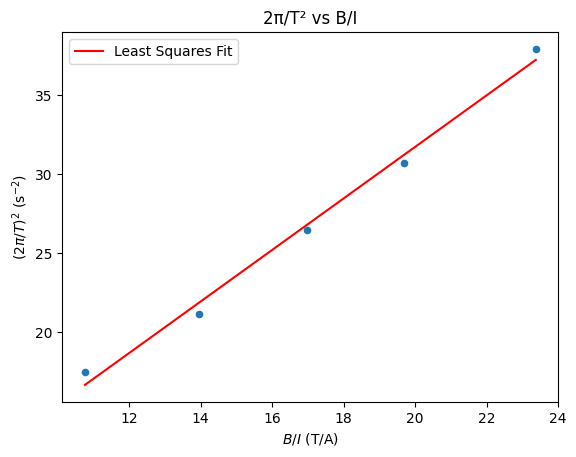

In [27]:
df.plot.scatter(x="B_upon_I", y="2pi_upon_T_sq")

plt.plot(
    df["B_upon_I"],
    intercept + slope * df["B_upon_I"],
    color="red",
    label="Least Squares Fit",
)
plt.legend()
plt.title("2π/T² vs B/I")
plt.xlabel(r"$B/I$ (T/A)")
plt.ylabel(r"$(2\pi/T)^2$ (s$^{-2}$)")


In [28]:
df["T"]

0    1.020000
1    1.133818
2    1.220727
3    1.365455
4    1.502182
Name: T, dtype: float64

Slope (T²/(1/B)): 4.784224445942074e-05
Intercept: 0.001462323639657398
R-squared: 0.9886633992510994
p-value: 0.0005140397086990093


Text(0.5, 1.0, 'Linear Regression of T² vs 1/B')

<Figure size 640x480 with 0 Axes>

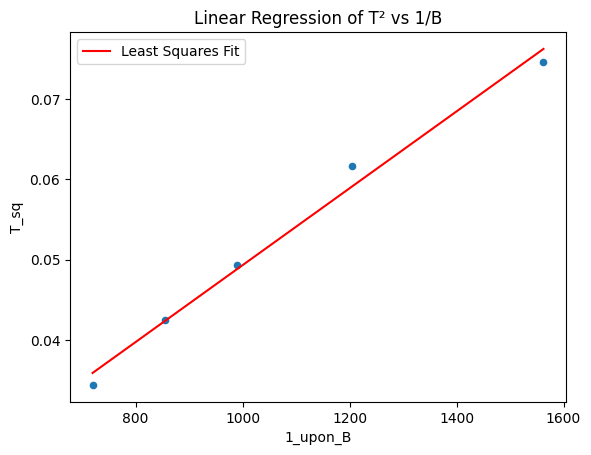

In [29]:
# Linear regression for T² vs 1/B
df["T_sq"] = (df["T"] / 5.5) ** 2
df["1_upon_B"] = 1 / df["B"]

(
    slope_t2_1overb,
    intercept_t2_1overb,
    r_value_t2_1overb,
    p_value_t2_1overb,
    std_err_t2_1overb,
) = stats.linregress(df["1_upon_B"], df["T_sq"])

print(f"Slope (T²/(1/B)): {slope_t2_1overb}")
print(f"Intercept: {intercept_t2_1overb}")
print(f"R-squared: {r_value_t2_1overb**2}")
print(f"p-value: {p_value_t2_1overb}")

plt.figure()
df.plot.scatter(x="1_upon_B", y="T_sq")
plt.plot(
    df["1_upon_B"],
    intercept_t2_1overb + slope_t2_1overb * df["1_upon_B"],
    color="red",
    label="Least Squares Fit",
)
plt.legend()
plt.title("Linear Regression of T² vs 1/B")


In [30]:
import scipy.constants as const

In [31]:
e = const.e
m = const.m_e
Va = 2000

In [32]:
v = (2 * e * Va / m) ** 0.5
print(f"{v:.3e}")

2.652e+07


In [33]:
v

26524102.309997212

In [34]:
e

1.602176634e-19

In [35]:
m

9.1093837139e-31

In [36]:
r = 0.35

In [37]:
v

26524102.309997212

In [38]:
(m * v) / (e * r)

0.000430874956483028

In [39]:
const.c

299792458.0

In [40]:
v / const.c

0.08847488187977434

In [41]:
c = const.c

In [42]:
v = 3e7

In [43]:
1 / np.sqrt(1 - (v / c) ** 2)

np.float64(1.005044845777813)

In [44]:
(m * v) / (e * r)

0.00048733972382615943

In [45]:
c

299792458.0

In [46]:
e

1.602176634e-19

In [47]:
m

9.1093837139e-31

In [48]:
Va = 2000
Va

2000

In [49]:
((e * Va) / (m * c**2)) + 1

1.00391390236182

In [50]:
mu_0 = const.mu_0
D = 0.155
I = 0.1238
N = 320

In [51]:
B = 16 * mu_0 * N * I / (np.sqrt(125) * (0.155))
B

np.float64(0.00045963571257503436)

In [52]:
delta_I = 0.0001
delta_D = 0.001
I = 0.1238
D = 0.155

fracI = delta_I / I
fracD = delta_D / D

delta_B = B * (fracI**2 + fracD**2) ** 0.5
delta_B

np.float64(2.9885433546737315e-06)

In [53]:
B

np.float64(0.00045963571257503436)